In [ ]:
!SAM2_BUILD_CUDA=0 pip install -q "git+https://github.com/facebookresearch/sam2.git" huggingface_hub


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 15.1 MB/s eta 0:00:00


In [5]:
from google.colab import files
uploaded = files.upload()
print(list(uploaded))


Saving man-enjoying-nature-stockcake.jpg to man-enjoying-nature-stockcake.jpg
['man-enjoying-nature-stockcake.jpg']


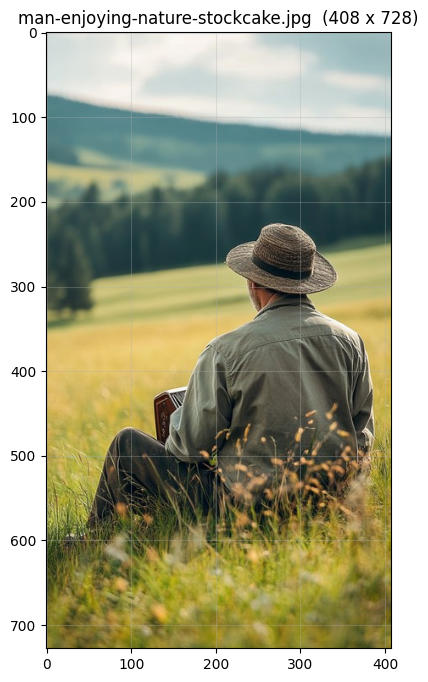

In [6]:
import cv2, numpy as np, matplotlib.pyplot as plt
for name, data in uploaded.items():
    img = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_COLOR)
    plt.figure(figsize=(8, 8)); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"{name}  ({img.shape[1]} x {img.shape[0]})"); plt.grid(alpha=0.3); plt.show()

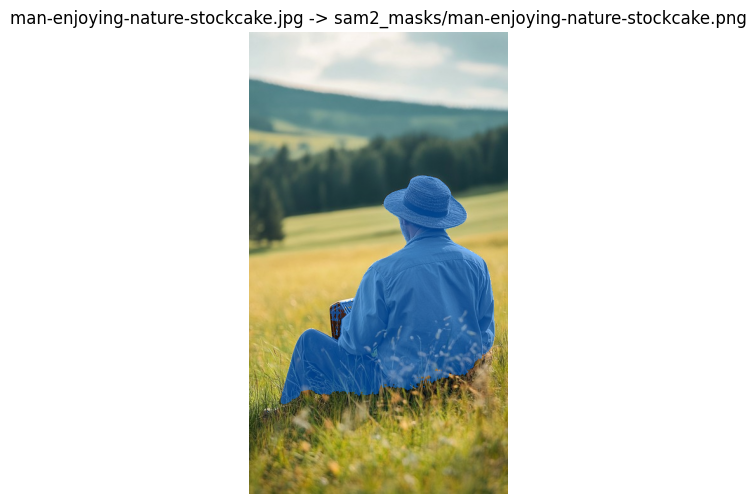

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import os, torch
from sam2.sam2_image_predictor import SAM2ImagePredictor

# One box per person: [x0, y0, x1, y1]. Use the SAME box as your classical method.
BOXES = {
    "astronaut.png": [[20, 0, 370, 511]],
    # "my_photo.jpg":  [[100, 50, 400, 600]],
    # "thermal1.jpg":  [[120, 40, 260, 400], [300, 50, 420, 410]],   # two people
}

device = "cuda" if torch.cuda.is_available() else "cpu"
predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2.1-hiera-large", device=device)

os.makedirs("sam2_masks", exist_ok=True)
for name, data in uploaded.items():
    bgr = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_COLOR)
    h, w = bgr.shape[:2]
    boxes = BOXES.get(name, [[int(.05*w), int(.05*h), int(.95*w), int(.95*h)]])
    predictor.set_image(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    person = np.zeros((h, w), bool)
    for b in boxes:
        masks, _, _ = predictor.predict(box=np.array(b, np.float32), multimask_output=False)
        person |= masks[0] > 0
    out = os.path.join("sam2_masks", os.path.splitext(name)[0] + ".png")
    cv2.imwrite(out, person.astype(np.uint8) * 255)

    # preview: SAM2 result in blue on the image
    ov = bgr.copy(); ov[person] = (0.5 * ov[person] + [127, 60, 0]).astype(np.uint8)
    plt.figure(figsize=(6, 6)); plt.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
    plt.title(f"{name} -> {out}"); plt.axis("off"); plt.show()

!zip -qr sam2_masks.zip sam2_masks
files.download("sam2_masks.zip")